# Image Classification Pipeline -- Complete Hackathon Template
# By: Parinthapat Pengpun
## Super AI Engineer Program -- Level 1

**What this notebook does:** A COMPLETE, copy-pasteable image classification pipeline using PyTorch. This is the exact workflow you will use in every image classification hackathon.

**Pipeline steps:**
1. Install & import
2. Download & explore dataset
3. Define transforms (augmentation)
4. Create DataLoaders
5. Load pretrained model & replace head
6. Train (standard PyTorch loop)
7. Evaluate with detailed metrics
8. Visualize predictions
9. Generate Kaggle submission CSV
10. Customization guide

**Runtime:** < 5 minutes total on free Google Colab T4 GPU
**Dataset:** Oxford Flowers-102 (subset -- 10 classes, ~200 images)


---
## Cell 1: Setup & Installs


In [1]:
# STEP 1: Install & import everything we need
# Pinned versions for reproducibility -- update as needed
!pip install torch torchvision matplotlib scikit-learn pandas Pillow -q

import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Using device: cuda
GPU: Tesla T4
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


---
## Cell 2: Download & Explore Dataset


In [2]:
# STEP 2: Download dataset and organize into train/val/test folders
# We use Flowers-102 from torchvision and reorganize a 10-class subset
# into the ImageFolder structure: data/{train,val,test}/class_name/*.jpg

from torchvision.datasets import Flowers102
from PIL import Image

DATA_ROOT = "data"
SUBSET_CLASSES = 10  # Use first 10 classes for speed
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
# TEST_SPLIT = 0.15 (remainder)

# Download the dataset via torchvision
print("Downloading Flowers-102 dataset...")
flowers_train = Flowers102(root="./flowers_raw", split="train", download=True)
flowers_val = Flowers102(root="./flowers_raw", split="val", download=True)
flowers_test = Flowers102(root="./flowers_raw", split="test", download=True)

# Flower class names (first 10)
# Flowers-102 labels are 0-indexed; we pick classes 0-9
FLOWER_NAMES = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells",
    "sweet pea", "english marigold", "tiger lily", "moon orchid",
    "bird of paradise", "monkshood", "globe thistle"
]

# Combine all splits and filter to our subset of classes
all_images = []
for dataset in [flowers_train, flowers_val, flowers_test]:
    for idx in range(len(dataset)):
        img_path = dataset._image_files[idx]
        label = dataset._labels[idx]
        if label < SUBSET_CLASSES:
            all_images.append((img_path, label))

print(f"Total images in {SUBSET_CLASSES}-class subset: {len(all_images)}")

# Shuffle and split into train/val/test
random.shuffle(all_images)

n_total = len(all_images)
n_train = int(n_total * TRAIN_SPLIT)
n_val = int(n_total * VAL_SPLIT)

train_imgs = all_images[:n_train]
val_imgs = all_images[n_train:n_train + n_val]
test_imgs = all_images[n_train + n_val:]

# Create directory structure and copy images
for split_name, split_imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
    for img_path, label in split_imgs:
        class_name = FLOWER_NAMES[label].replace(" ", "_")
        dest_dir = os.path.join(DATA_ROOT, split_name, class_name)
        os.makedirs(dest_dir, exist_ok=True)
        dest_path = os.path.join(dest_dir, os.path.basename(str(img_path)))
        if not os.path.exists(dest_path):
            shutil.copy2(str(img_path), dest_path)

# Print dataset statistics
print(f"\n{'='*50}")
print(f"DATASET SUMMARY")
print(f"{'='*50}")
for split_name in ["train", "val", "test"]:
    split_dir = os.path.join(DATA_ROOT, split_name)
    classes = sorted(os.listdir(split_dir))
    total = 0
    print(f"\n{split_name.upper()} set:")
    for cls in classes:
        cls_dir = os.path.join(split_dir, cls)
        if os.path.isdir(cls_dir):
            count = len([f for f in os.listdir(cls_dir) if not f.startswith('.')])
            total += count
            print(f"  {cls:35s} {count:4d} images")
    print(f"  {'TOTAL':35s} {total:4d} images")

print(f"\nClasses: {sorted(os.listdir(os.path.join(DATA_ROOT, 'train')))}")

100%|██████████| 345M/345M [00:20<00:00, 17.0MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.56MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 50.1MB/s]


Total images in 10-class subset: 522

DATASET SUMMARY

TRAIN set:
  bird_of_paradise                      59 images
  canterbury_bells                      28 images
  english_marigold                      42 images
  globe_thistle                         36 images
  hard-leaved_pocket_orchid             41 images
  monkshood                             30 images
  moon_orchid                           30 images
  pink_primrose                         29 images
  sweet_pea                             34 images
  tiger_lily                            36 images
  TOTAL                                365 images

VAL set:
  bird_of_paradise                      11 images
  canterbury_bells                       7 images
  english_marigold                      11 images
  globe_thistle                          3 images
  hard-leaved_pocket_orchid              7 images
  monkshood                             11 images
  moon_orchid                            6 images
  pink_primrose         

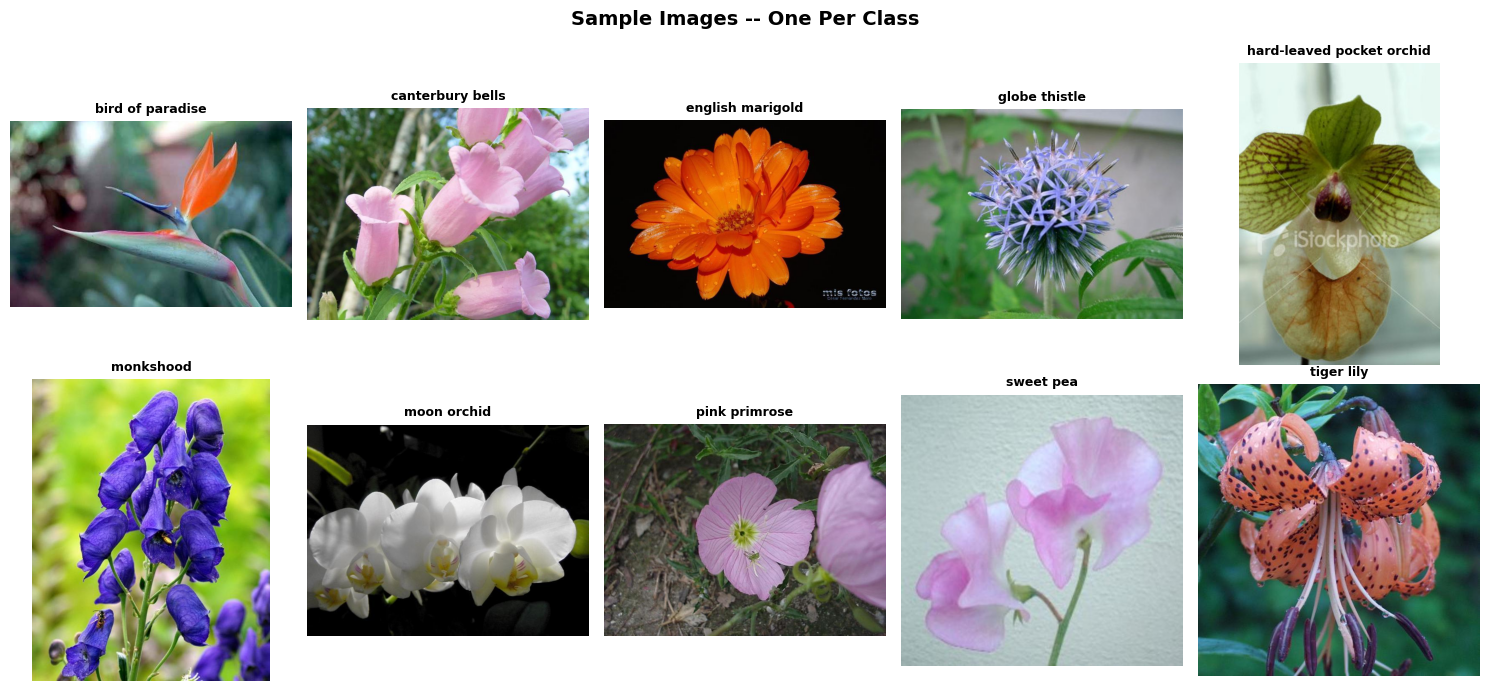

In [3]:
# Show sample images from the dataset
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
train_dir = os.path.join(DATA_ROOT, "train")
classes = sorted(os.listdir(train_dir))

for idx, cls in enumerate(classes[:10]):
    ax = axes[idx // 5][idx % 5]
    cls_dir = os.path.join(train_dir, cls)
    img_files = [f for f in os.listdir(cls_dir) if not f.startswith('.')]
    if img_files:
        img = Image.open(os.path.join(cls_dir, img_files[0]))
        ax.imshow(img)
    ax.set_title(cls.replace("_", " "), fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle("Sample Images -- One Per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 3: Define Transforms

The normalize values `[0.485, 0.456, 0.406]` and `[0.229, 0.224, 0.225]` are the ImageNet mean and std. Use these whenever you fine-tune an ImageNet-pretrained model.

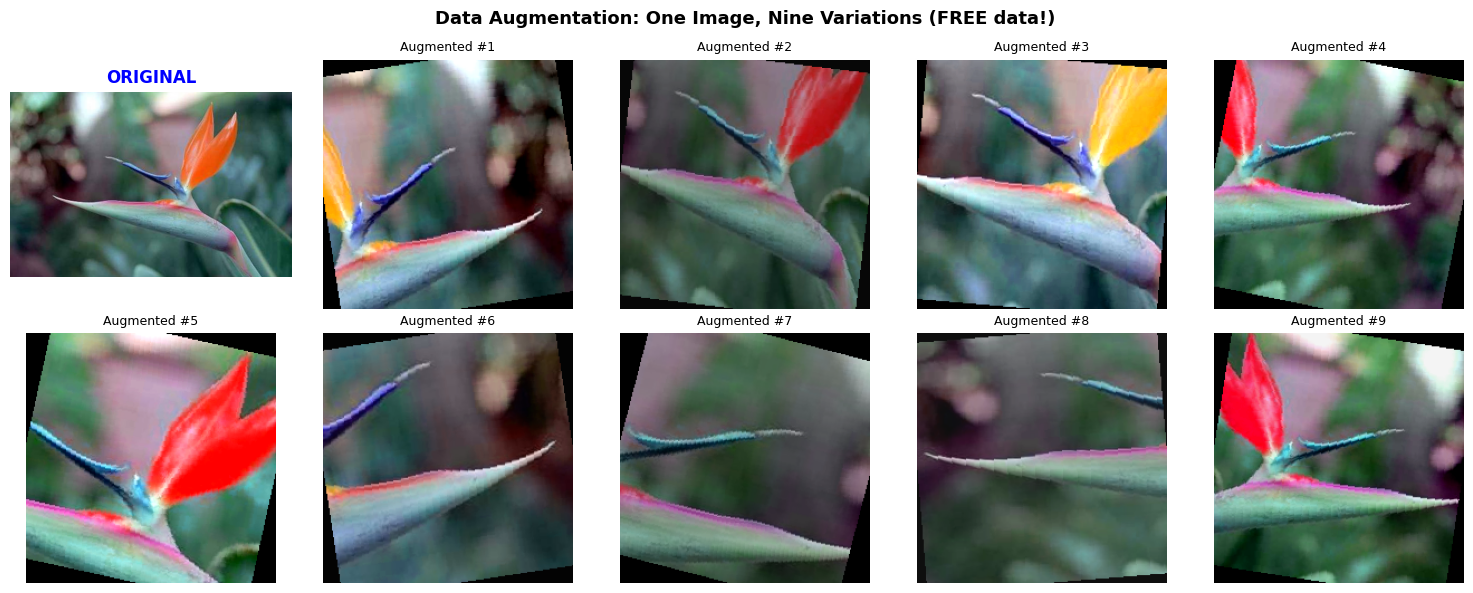

Train transform: augmentation ON (random crop, flip, rotate, color jitter)
Val/test transform: augmentation OFF (resize + center crop only)


In [4]:
# STEP 3: Define transforms -- augmentation for train, clean for val/test
# These are the standard transforms for any ImageNet-pretrained model.

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Show augmentation effect: same image transformed 8 different ways
sample_class = sorted(os.listdir(os.path.join(DATA_ROOT, "train")))[0]
sample_dir = os.path.join(DATA_ROOT, "train", sample_class)
sample_files = [f for f in os.listdir(sample_dir) if not f.startswith('.')]
sample_img = Image.open(os.path.join(sample_dir, sample_files[0])).convert("RGB")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0][0].imshow(sample_img)
axes[0][0].set_title("ORIGINAL", fontweight='bold', color='blue')
axes[0][0].axis('off')

for i in range(1, 10):
    ax = axes[i // 5][i % 5]
    # Apply augmentation (skip normalize for visualization)
    vis_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    ])
    augmented = vis_transform(sample_img)
    ax.imshow(augmented)
    ax.set_title(f"Augmented #{i}", fontsize=9)
    ax.axis('off')

plt.suptitle("Data Augmentation: One Image, Nine Variations (FREE data!)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Train transform: augmentation ON (random crop, flip, rotate, color jitter)")
print("Val/test transform: augmentation OFF (resize + center crop only)")

---
## Cell 4: Create DataLoaders

In [5]:
# STEP 4: Create datasets and dataloaders
# ImageFolder automatically reads the folder structure:
#   data/train/class_a/*.jpg  -> label 0
#   data/train/class_b/*.jpg  -> label 1
#   ...

train_dataset = ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=train_transform)
val_dataset = ImageFolder(os.path.join(DATA_ROOT, 'val'), transform=val_transform)
test_dataset = ImageFolder(os.path.join(DATA_ROOT, 'test'), transform=val_transform)  # Same as val!

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# The class-to-index mapping (ImageFolder assigns labels alphabetically)
print(f"Classes ({len(train_dataset.classes)} total):")
for idx, cls in enumerate(train_dataset.classes):
    print(f"  [{idx}] {cls}")

print(f"\nTraining images:   {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images:       {len(test_dataset)}")
print(f"\nBatch size: 32")
print(f"Training batches:  {len(train_loader)}")
print(f"Validation batches:{len(val_loader)}")

Classes (10 total):
  [0] bird_of_paradise
  [1] canterbury_bells
  [2] english_marigold
  [3] globe_thistle
  [4] hard-leaved_pocket_orchid
  [5] monkshood
  [6] moon_orchid
  [7] pink_primrose
  [8] sweet_pea
  [9] tiger_lily

Training images:   365
Validation images: 78
Test images:       79

Batch size: 32
Training batches:  12
Validation batches:3


---
## Cell 5: Load Pretrained Model & Replace Head


In [6]:
# STEP 5: Load pretrained ResNet-18 and replace the classification head
# This is the standard transfer learning pattern:
#   1. Load a model pretrained on ImageNet (1.2 million images, 1000 classes)
#   2. Freeze all the pretrained layers (they already know how to "see")
#   3. Replace the final layer with one matching YOUR number of classes

model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze the pretrained backbone -- do NOT update these weights
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully-connected layer
# ResNet-18's fc layer: 512 features -> 1000 classes (ImageNet)
# We change it to:    512 features -> NUM_CLASSES (our flowers)
NUM_CLASSES = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Move to GPU
model = model.to(device)

# Count parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
frozen_params = total_params - trainable_params

print(f"Model: ResNet-18 (pretrained on ImageNet)")
print(f"Device: {device}")
print(f"{'='*40}")
print(f"Total parameters:     {total_params:>12,}")
print(f"Frozen (pretrained):  {frozen_params:>12,}")
print(f"Trainable (new head): {trainable_params:>12,}")
print(f"{'='*40}")
print(f"We are training only {trainable_params/total_params*100:.1f}% of the model!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 126MB/s]


Model: ResNet-18 (pretrained on ImageNet)
Device: cuda
Total parameters:       11,181,642
Frozen (pretrained):    11,176,512
Trainable (new head):        5,130
We are training only 0.0% of the model!


---
## Cell 6: Training Loop

Run time: ~1-2 minutes on T4 GPU

In [7]:
# STEP 6: Train the model
# Standard PyTorch training loop -- this is the pattern you will reuse everywhere.

import time

# Loss function, optimizer, and scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)  # Only optimize the new head!
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

NUM_EPOCHS = 5

# Track metrics for plotting
history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

print(f"Training for {NUM_EPOCHS} epochs...")
print(f"{'='*70}")

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # ---- TRAINING PHASE ----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()           # 1. Clear old gradients
        outputs = model(images)         # 2. Forward pass
        loss = criterion(outputs, labels)  # 3. Compute loss
        loss.backward()                 # 4. Backward pass (compute gradients)
        optimizer.step()                # 5. Update weights

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total

    # ---- VALIDATION PHASE ----
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():  # No gradients needed for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100. * val_correct / val_total
    scheduler.step()

    # Log
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.1f}% | "
          f"Val Acc: {val_acc:.1f}% | "
          f"LR: {current_lr:.6f}")

elapsed = time.time() - start_time
print(f"{'='*70}")
print(f"Training complete in {elapsed:.1f} seconds!")
print(f"Best validation accuracy: {max(history['val_acc']):.1f}%")

Training for 5 epochs...
Epoch 1/5 | Train Loss: 2.1433 | Train Acc: 25.5% | Val Acc: 50.0% | LR: 0.001000
Epoch 2/5 | Train Loss: 1.6566 | Train Acc: 53.2% | Val Acc: 74.4% | LR: 0.001000
Epoch 3/5 | Train Loss: 1.2907 | Train Acc: 72.1% | Val Acc: 78.2% | LR: 0.000100
Epoch 4/5 | Train Loss: 1.0831 | Train Acc: 81.9% | Val Acc: 78.2% | LR: 0.000100
Epoch 5/5 | Train Loss: 1.0269 | Train Acc: 82.5% | Val Acc: 78.2% | LR: 0.000100
Training complete in 22.2 seconds!
Best validation accuracy: 78.2%


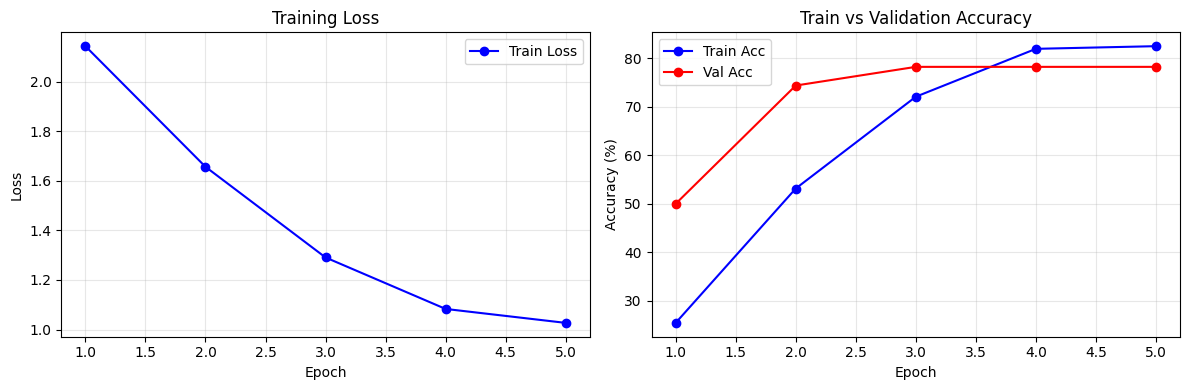

In [8]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, NUM_EPOCHS + 1)

# Loss curve
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc')
ax2.plot(epochs_range, history['val_acc'], 'r-o', label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Train vs Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Cell 7: Evaluation -- Detailed Metrics

CLASSIFICATION REPORT
                           precision    recall  f1-score   support

         bird of paradise       0.79      1.00      0.88        11
         canterbury bells       0.40      0.29      0.33         7
         english marigold       0.92      1.00      0.96        11
            globe thistle       1.00      1.00      1.00         3
hard-leaved pocket orchid       0.88      1.00      0.93         7
                monkshood       0.60      0.82      0.69        11
              moon orchid       0.67      1.00      0.80         6
            pink primrose       1.00      0.83      0.91         6
                sweet pea       1.00      0.18      0.31        11
               tiger lily       1.00      1.00      1.00         5

                 accuracy                           0.78        78
                macro avg       0.82      0.81      0.78        78
             weighted avg       0.81      0.78      0.75        78



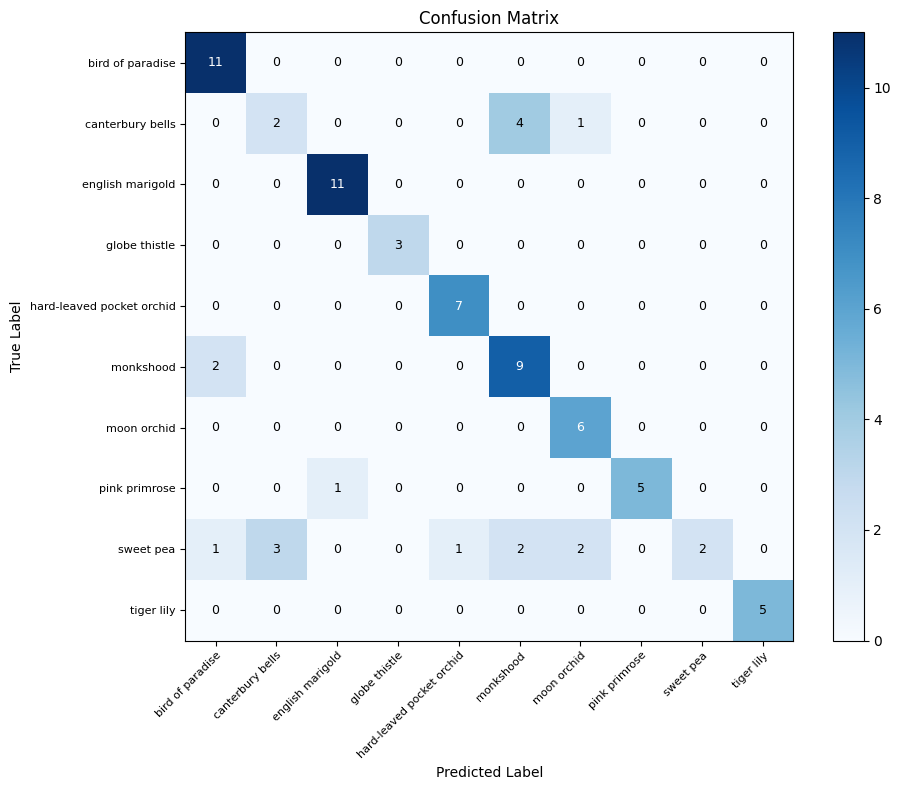


TIP: Look at the off-diagonal cells -- those are misclassifications.
If two classes are often confused, consider adding more data or targeted augmentation.


In [9]:
# STEP 7: Detailed evaluation on the validation set
# classification_report gives you precision, recall, and F1 for EVERY class.
# confusion_matrix shows which classes get confused with each other.

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report -- per-class metrics
class_names = [c.replace("_", " ") for c in train_dataset.classes]
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix visualization
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Labels
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=class_names,
       yticklabels=class_names,
       ylabel='True Label',
       xlabel='Predicted Label',
       title='Confusion Matrix')

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)

# Add text annotations in each cell
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=9)

plt.tight_layout()
plt.show()

print("\nTIP: Look at the off-diagonal cells -- those are misclassifications.")
print("If two classes are often confused, consider adding more data or targeted augmentation.")

---
## Cell 8: Visualize Predictions

In [10]:
# STEP 8: Visualize predictions -- see what the model gets right and wrong

def denormalize(tensor):
    """Undo ImageNet normalization for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)

# Grab a batch from validation set
model.eval()
images, labels = next(iter(val_loader))
images_gpu = images.to(device)

with torch.no_grad():
    outputs = model(images_gpu)
    probs = torch.softmax(outputs, dim=1)
    confidences, predicted = probs.max(1)

# Show predictions
n_show = min(16, len(images))
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for i in range(n_show):
    ax = axes[i // 4][i % 4]
    img = denormalize(images[i])
    ax.imshow(img.permute(1, 2, 0).numpy())

    true_label = class_names[labels[i]]
    pred_label = class_names[predicted[i].cpu()]
    conf = confidences[i].cpu().item()

    is_correct = (predicted[i].cpu() == labels[i])

    if is_correct:
        ax.set_title(f"Pred: {pred_label}\n({conf:.0%})",
                     color='green', fontsize=9, fontweight='bold')
    else:
        ax.set_title(f"Pred: {pred_label} ({conf:.0%})\nTrue: {true_label}",
                     color='red', fontsize=9, fontweight='bold')
        # Red border for wrong predictions
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(3)

    ax.axis('off')

plt.suptitle("Model Predictions (GREEN = correct, RED = wrong)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

---
## Cell 9: Generate Kaggle Submission CSV

In [11]:
# STEP 9: Generate Kaggle submission CSV
# In a real competition, you would have a test set WITHOUT labels.
# Here we simulate by running inference on our test split.

# The test_dataset uses val_transform (no augmentation -- just resize + normalize)
model.eval()
predictions = []
filenames = []
pred_indices = []

with torch.no_grad():
    sample_idx = 0
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        for i in range(len(images)):
            # Get the original filename from the dataset
            filepath = test_dataset.samples[sample_idx][0]
            filenames.append(os.path.basename(filepath))
            pred_indices.append(predicted[i].cpu().item())
            sample_idx += 1

# Create submission DataFrame
submission = pd.DataFrame({
    'image_id': filenames,
    'label': [train_dataset.classes[p] for p in pred_indices],
    'label_index': pred_indices,
})

# Save to CSV
submission.to_csv('submission.csv', index=False)

print("SUBMISSION FILE GENERATED!")
print(f"{'='*50}")
print(f"Total predictions: {len(submission)}")
print(f"Saved to: submission.csv")
print(f"\nFirst 10 rows:")
print(submission.head(10).to_string(index=False))
print(f"\nLabel distribution in predictions:")
print(submission['label'].value_counts().to_string())

# Verify the file exists and show its size
file_size = os.path.getsize('submission.csv')
print(f"\nFile size: {file_size:,} bytes")
print("\nREADY TO SUBMIT!")

SUBMISSION FILE GENERATED!
Total predictions: 79
Saved to: submission.csv

First 10 rows:
       image_id            label  label_index
image_03290.jpg bird_of_paradise            0
image_03291.jpg bird_of_paradise            0
image_03292.jpg bird_of_paradise            0
image_03295.jpg bird_of_paradise            0
image_03297.jpg bird_of_paradise            0
image_03308.jpg bird_of_paradise            0
image_03315.jpg bird_of_paradise            0
image_03320.jpg bird_of_paradise            0
image_03321.jpg bird_of_paradise            0
image_03325.jpg bird_of_paradise            0

Label distribution in predictions:
label
bird_of_paradise             16
hard-leaved_pocket_orchid    13
english_marigold             11
monkshood                     8
moon_orchid                   7
globe_thistle                 6
sweet_pea                     6
canterbury_bells              4
pink_primrose                 4
tiger_lily                    4

File size: 2,722 bytes

READY TO SUBMIT!


---
## Cell 10: Save Your Model

Always save your best model so you can reload it later without retraining.

In [12]:
# STEP 10: Save the trained model
# Save the model weights so you can reload later without retraining

torch.save({
    'model_state_dict': model.state_dict(),
    'classes': train_dataset.classes,
    'num_classes': NUM_CLASSES,
}, 'flower_classifier.pth')

print("Model saved to flower_classifier.pth")
print(f"File size: {os.path.getsize('flower_classifier.pth') / 1024 / 1024:.1f} MB")

# How to reload later:
# checkpoint = torch.load('flower_classifier.pth')
# model = models.resnet18(weights=None)
# model.fc = nn.Linear(512, checkpoint['num_classes'])
# model.load_state_dict(checkpoint['model_state_dict'])
# model.eval()

Model saved to flower_classifier.pth
File size: 42.7 MB


---
## What to Change for YOUR Dataset

This notebook is a **template**. Here is exactly what to modify for your own hackathon:

### 1. Change the data path
```python
# Replace the download cell (Cell 2) with:
DATA_ROOT = "/path/to/your/kaggle/data"
# Make sure your data follows the ImageFolder structure:
#   data/train/class_a/*.jpg
#   data/train/class_b/*.jpg
#   data/val/class_a/*.jpg
#   ...
```

### 2. NUM_CLASSES is automatic
If you use `ImageFolder`, `NUM_CLASSES = len(train_dataset.classes)` handles everything. No manual change needed.

### 3. Consider your augmentations
- **General images (animals, objects, scenes):** Use all augmentations as-is
- **Text/document images:** REMOVE `RandomHorizontalFlip` (text should not be flipped!)
- **Medical images:** Be careful with `ColorJitter` -- color may be diagnostically important
- **Satellite/aerial images:** ADD `RandomVerticalFlip` (orientation does not matter)

### 4. If accuracy is low, try these (in order):
1. **Unfreeze the last block** of ResNet for fine-tuning:
   ```python
   for param in model.layer4.parameters():
       param.requires_grad = True
   # Use a LOWER learning rate: optimizer = optim.Adam(model.parameters(), lr=0.0001)
   ```
2. **Switch to a bigger model:** `models.resnet50(weights='IMAGENET1K_V1')` or `models.efficientnet_b0(weights='IMAGENET1K_V1')`
3. **Train longer:** Increase `NUM_EPOCHS` to 10 or 15
4. **More augmentation:** Add `transforms.RandomVerticalFlip()`, `transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))`

### 5. If training is slow:
- Reduce image size: change `224` to `128` in transforms
- Reduce batch size: change `32` to `16`
- Use a smaller model: `resnet18` is already the smallest ResNet

### 6. If you have class imbalance:
```python
# Weighted loss -- give more weight to rare classes
from collections import Counter
class_counts = Counter([label for _, label in train_dataset.samples])
weights = [1.0 / class_counts[i] for i in range(NUM_CLASSES)]
weights = torch.tensor(weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
```

### Key files to remember:
- `submission.csv` -- your Kaggle submission
- `flower_classifier.pth` -- your trained model weights